In [91]:
%env ECOLOGICAL_NEURO_DATA_ROOT=/media/labuser/NA_1_2025/EcoNeuro


env: ECOLOGICAL_NEURO_DATA_ROOT=/media/labuser/NA_1_2025/EcoNeuro


In [92]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'svg'
%config InlineBackend.print_figure_kwargs = {'bbox_inches': None}

from pathlib import Path

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display
from pynwb import NWBHDF5IO
from scipy.signal import savgol_filter
from src.ecological_neuro.interactive import *
from src.ecological_neuro.plotting import *
from src.ecological_neuro.utils import *

sns.set_theme(context='talk', style='ticks', palette='colorblind')
PALETTE = sns.color_palette('colorblind')
plt.rcParams.update({
    'axes.spines.top': False,
    'axes.spines.right': False,
})


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Explore Indy random-target data

Indy controlled a virtual hand with two finger groups in a self-paced random-target acquisition task. The training asset contains continuous cursor, finger, and target positions; the test asset is electrophysiology-only.


In [93]:
import os

indy_paths = sorted((Path(os.environ['ECOLOGICAL_NEURO_DATA_ROOT']) / '000129' / 'sub-Indy').glob('*.nwb'))

indy_file = widgets.Dropdown(
    options=indy_paths,
    value=next(path for path in indy_paths if 'train' in path.name),
    description='NWB file:',
)

@widgets.interact(nwb_path=indy_file)
def explore_nwb(nwb_path):
    with NWBHDF5IO(nwb_path, 'r', load_namespaces=True) as io:
        display(io.read())


interactive(children=(Dropdown(description='NWB file:', index=1, options=(PosixPath('/media/labuser/NA_1_2025/…

In [94]:
with NWBHDF5IO(indy_file.value, 'r', load_namespaces=True) as io:
    nwb = io.read()
    behavior = nwb.processing['behavior'].data_interfaces
    cursor = behavior['cursor_pos']
    time = cursor.starting_time + np.arange(len(cursor.data)) / cursor.rate
    cursor_pos = np.asarray(cursor.data[:])
    target_pos = np.asarray(behavior['target_pos'].data[:])
    finger_pos = np.asarray(behavior['finger_pos'].data[:])
    finger_vel = np.asarray(behavior['finger_vel'].data[:])

finite_target = np.all(np.isfinite(target_pos), axis=1)
target_changes = np.flatnonzero(
    finite_target[:-1]
    & finite_target[1:]
    & np.any(target_pos[:-1] != target_pos[1:], axis=1)
) + 1
start_idx = target_changes[:-1]
stop_idx = target_changes[1:]
valid = np.array([finite_target[i:j].all() for i, j in zip(start_idx, stop_idx)])
start_idx = start_idx[valid]
stop_idx = stop_idx[valid]

reaches = pd.DataFrame({
    'reach': np.arange(len(start_idx)),
    'start_time': time[start_idx],
    'stop_time': time[stop_idx],
    'target_pos': [target_pos[i] for i in start_idx],
})
reaches['time'] = [time[i:j] for i, j in zip(start_idx, stop_idx)]
reaches['cursor_pos'] = [cursor_pos[i:j] for i, j in zip(start_idx, stop_idx)]
reaches['finger_pos'] = [finger_pos[i:j] for i, j in zip(start_idx, stop_idx)]
reaches['finger_vel'] = [finger_vel[i:j] for i, j in zip(start_idx, stop_idx)]


/home/labuser/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.5.0 because version 1.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
/home/labuser/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.4.0 because version 2.7.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
/home/labuser/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-experimental' version 0.1.0 because version 0.5.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."


In [95]:
SMOOTHING_SIGMA_S = 0.10
MAX_GAP_MULTIPLIER = 3.0

def calculate_reach_kinematics(row):
    reach_time = row['time']
    cursor = row['cursor_pos']
    velocity = np.column_stack([
        differentiate_time_series(reach_time, cursor[:, axis], max_gap_multiplier=MAX_GAP_MULTIPLIER)
        for axis in range(2)
    ])
    speed = np.linalg.norm(velocity, axis=1)
    speed_smoothed = smooth_time_series(
        reach_time, speed, smoothing_sigma_s=SMOOTHING_SIGMA_S,
        max_gap_multiplier=MAX_GAP_MULTIPLIER,
    )
    acceleration = differentiate_time_series(
        reach_time, speed_smoothed, max_gap_multiplier=MAX_GAP_MULTIPLIER,
    )
    return pd.Series({
        'speed': speed,
        'speed_smoothed': speed_smoothed,
        'acceleration': acceleration,
    })

reaches[['speed', 'speed_smoothed', 'acceleration']] = reaches.apply(
    calculate_reach_kinematics, axis=1,
)


In [96]:
def path_efficiency(cursor):
    cursor = savgol_filter(cursor[::4], 15, 2, axis=0)
    path_length = np.linalg.norm(np.diff(cursor, axis=0), axis=1).sum()
    return np.linalg.norm(cursor[-1] - cursor[0]) / path_length

reaches['path_efficiency'] = reaches['cursor_pos'].apply(path_efficiency)
straight_reaches = reaches[reaches['path_efficiency'] >= 0.90].copy()
print(f'{len(straight_reaches)} of {len(reaches)} reaches retained')


203 of 541 reaches retained


In [97]:
MIN_BRAKING_DURATION_S = 0.20
MAX_ACCELERATION_INTERRUPTION_S = 0.05

def find_braking_period(row):
    event = detect_braking_period(
        row['time'], row['acceleration'], np.ones(len(row['time']), dtype=bool),
        len(row['time']) - 1, min_duration_s=MIN_BRAKING_DURATION_S,
        max_interruption_s=MAX_ACCELERATION_INTERRUPTION_S,
    )
    if event is None:
        return pd.Series({'braking_detected': False})

    onset_position = row['cursor_pos'][event.start_index]
    return pd.Series({
        'braking_detected': True,
        'braking_onset_index': event.start_index,
        'braking_onset_time': event.start_time_s,
        'braking_duration_s': event.duration_s,
        'braking_negative_fraction': event.negative_fraction,
        'braking_onset_x': onset_position[0],
        'braking_onset_y': onset_position[1],
    })

braking_columns = straight_reaches.apply(find_braking_period, axis=1)
straight_reaches[braking_columns.columns] = braking_columns
detected_braking_reaches = straight_reaches[straight_reaches['braking_detected']].copy()
print(f'{len(detected_braking_reaches)} of {len(straight_reaches)} straight reaches have detected braking')


139 of 203 straight reaches have detected braking


In [ ]:
@widgets.interact(reach=widgets.Dropdown(options=detected_braking_reaches['reach'], description='Reach:'))
def plot_reach(reach):
    row = detected_braking_reaches.loc[detected_braking_reaches['reach'] == reach].iloc[0]
    cursor = savgol_filter(row['cursor_pos'][::4], 15, 2, axis=0)
    speed = row['speed_smoothed'][::4]

    fig, ax = plt.subplots(figsize=(4, 4))
    trajectory = ax.scatter(cursor[:, 0], cursor[:, 1], c=speed, s=10, cmap='viridis')
    ax.scatter(*cursor[0], marker='o', s=100, color='black', label='Start')
    ax.scatter(*cursor[-1], marker='*', s=200, color='orange', label='Stop')
    ax.scatter(row['braking_onset_x'], row['braking_onset_y'], marker='x', s=150, color='red', linewidths=3, label='Braking onset')
    ax.set_xlabel('x (mm)')
    ax.set_ylabel('y (mm)')
    ax.legend()
    fig.colorbar(trajectory, ax=ax, label='Speed (mm/s)')
    plt.show()


interactive(children=(Dropdown(description='Reach:', options=(0, 1, 7, 10, 19, 20, 22, 31, 39, 47, 48, 58, 62,…

In [99]:
@widgets.interact(reach=widgets.Dropdown(options=detected_braking_reaches['reach'], description='Reach:'))
def plot_reach_acceleration(reach):
    row = detected_braking_reaches.loc[detected_braking_reaches['reach'] == reach].iloc[0]
    cursor = savgol_filter(row['cursor_pos'][::4], 15, 2, axis=0)
    acceleration = row['acceleration'][::4]
    color_limit = np.nanpercentile(np.abs(acceleration), 99)

    fig, ax = plt.subplots(figsize=(4, 4))
    trajectory = ax.scatter(
        cursor[:, 0], cursor[:, 1], c=acceleration, s=10, cmap='RdBu',
        vmin=-color_limit, vmax=color_limit,
    )
    ax.scatter(*cursor[0], marker='o', s=100, color='black', label='Start')
    ax.scatter(*cursor[-1], marker='*', s=200, color='orange', label='Stop')
    ax.scatter(row['braking_onset_x'], row['braking_onset_y'], marker='x', s=150, color='red', linewidths=3, label='Braking onset')
    ax.set_xlabel('x (mm)')
    ax.set_ylabel('y (mm)')
    ax.legend()
    fig.colorbar(trajectory, ax=ax, label='Acceleration (mm/s²)')
    plt.show()


interactive(children=(Dropdown(description='Reach:', options=(0, 1, 7, 10, 19, 20, 22, 31, 39, 47, 48, 58, 62,…

In [100]:
MIN_CLOSURE_SPEED_MM_S = 10.0

metric_rows = []
for row in detected_braking_reaches.itertuples(index=False):
    onset_index = int(row.braking_onset_index)
    arrival_index = len(row.time) - 1
    remaining_gap = np.linalg.norm(row.cursor_pos - row.target_pos, axis=1)
    smoothed_gap = smooth_time_series(
        row.time, remaining_gap, smoothing_sigma_s=SMOOTHING_SIGMA_S,
        max_gap_multiplier=MAX_GAP_MULTIPLIER,
    )
    total_gap_closed = smoothed_gap[0] - smoothed_gap[arrival_index]
    normalized_distance = (
        (smoothed_gap[0] - smoothed_gap[onset_index]) / total_gap_closed
        if np.isfinite(total_gap_closed) and total_gap_closed > 0 else np.nan
    )
    metrics = calculate_braking_metrics(
        row.time, remaining_gap, row.speed_smoothed, row.acceleration,
        onset_index, arrival_index, closure_speed_floor=MIN_CLOSURE_SPEED_MM_S,
        smoothing_sigma_s=SMOOTHING_SIGMA_S, max_gap_multiplier=MAX_GAP_MULTIPLIER,
    )
    metric_rows.append({
        'reach': row.reach,
        'path_efficiency': row.path_efficiency,
        'target_x_mm': row.target_pos[0],
        'target_y_mm': row.target_pos[1],
        'position_x_mm': row.braking_onset_x,
        'position_y_mm': row.braking_onset_y,
        'normalized_distance_at_onset': normalized_distance,
        **vars(metrics),
    })

spatial_metric_names = {
    'remaining_gap_at_onset': 'remaining_gap_at_onset_mm',
    'closure_speed_at_onset': 'closure_speed_at_onset_mm_s',
    'speed_at_onset': 'speed_at_onset_mm_s',
    'acceleration_at_onset': 'acceleration_at_onset_mm_s2',
    'speed_at_arrival': 'speed_at_arrival_mm_s',
    'speed_reduction': 'speed_reduction_mm_s',
    'distance_travelled': 'distance_travelled_mm',
    'mean_deceleration': 'mean_deceleration_mm_s2',
    'max_deceleration': 'max_deceleration_mm_s2',
}
braking_metrics_df = pd.DataFrame(metric_rows).rename(columns=spatial_metric_names)

breaking_onset_metrics = braking_metrics_df[[
    'reach', 'path_efficiency', 'time_to_arrival_s', 'remaining_gap_at_onset_mm',
    'normalized_distance_at_onset',
    'closure_speed_at_onset_mm_s', 'tau_at_onset_s', 'speed_at_onset_mm_s',
    'acceleration_at_onset_mm_s2',
]].copy()
breaking_onset_metrics.head()


,reach,path_efficiency,time_to_arrival_s,remaining_gap_at_onset_mm,normalized_distance_at_onset,closure_speed_at_onset_mm_s,tau_at_onset_s,speed_at_onset_mm_s,acceleration_at_onset_mm_s2
0,0,0.938803,0.628,29.875301,0.528856,145.680885,0.205074,166.514135,-5.252465
1,1,0.934883,0.364,4.866432,0.984328,18.589346,0.261786,52.076046,-2.591184
2,7,0.909791,0.637,15.542653,0.342621,37.967887,0.409363,40.132951,-0.471428
3,10,0.927235,0.601,44.660512,0.507028,246.928473,0.180864,251.425270,-2.012373
4,19,0.902131,0.416,7.138507,0.954323,38.908740,0.183468,55.890683,-1.403839


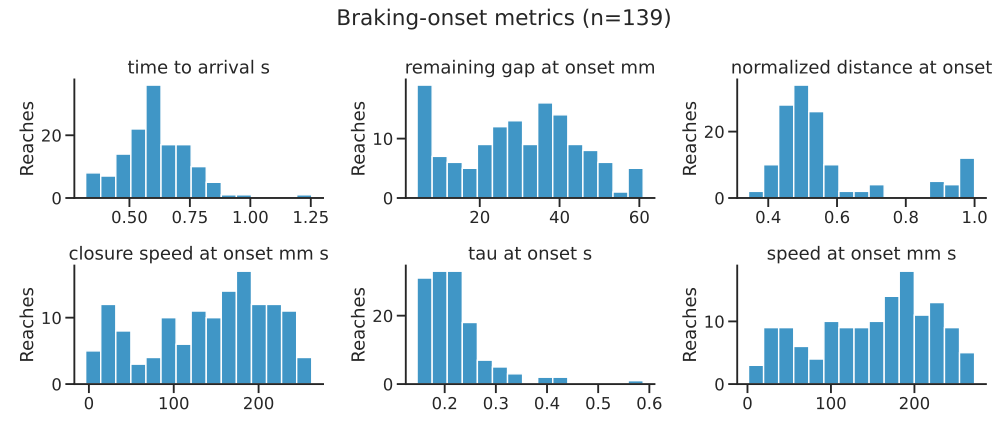

In [101]:
onset_metric_columns = [
    'time_to_arrival_s',
    'remaining_gap_at_onset_mm',
    'normalized_distance_at_onset',
    'closure_speed_at_onset_mm_s',
    'tau_at_onset_s',
    'speed_at_onset_mm_s',
]

fig, axes = plt.subplots(2, 3, figsize=(14, 6), layout = "tight")
for ax, metric in zip(axes.flat, onset_metric_columns):
    sns.histplot(breaking_onset_metrics[metric].dropna(), bins=15, ax=ax, color=PALETTE[0])
    ax.set(title=metric.replace('_', ' '), xlabel='', ylabel='Reaches')
for ax in axes.flat[len(onset_metric_columns):]:
    ax.remove()
fig.suptitle(f'Braking-onset metrics (n={len(breaking_onset_metrics)})')
plt.show()


In [102]:
selected_metrics = breaking_onset_metrics[onset_metric_columns]
medians = selected_metrics.median()
iqrs = selected_metrics.quantile(0.75) - selected_metrics.quantile(0.25)
normalized_iqr_table = pd.DataFrame({
    'median': medians,
    'iqr': iqrs,
    'normalized_iqr': iqrs / medians.abs().replace(0, np.nan),
}).sort_values('normalized_iqr')
normalized_iqr_table


,median,iqr,normalized_iqr
normalized_distance_at_onset,0.508696,0.101584,0.199695
time_to_arrival_s,0.595000,0.166500,0.279832
tau_at_onset_s,0.206469,0.063768,0.308851
speed_at_onset_mm_s,163.785741,109.616052,0.669265
closure_speed_at_onset_mm_s,156.685412,114.350703,0.729811
remaining_gap_at_onset_mm,29.875099,21.813154,0.730145


In [103]:
support_rows = []
for row in straight_reaches.itertuples(index=False):
    remaining_gap = np.linalg.norm(row.cursor_pos - row.target_pos, axis=1)
    smoothed_gap = smooth_time_series(
        row.time, remaining_gap, smoothing_sigma_s=SMOOTHING_SIGMA_S,
        max_gap_multiplier=MAX_GAP_MULTIPLIER,
    )
    support_rows.append({
        'reach': row.reach,
        'total_distance_mm': smoothed_gap[0] - smoothed_gap[-1],
        'peak_speed_mm_s': np.nanmax(row.speed_smoothed),
    })

straight_reach_support = pd.DataFrame(support_rows)
onset_support = breaking_onset_metrics[[
    'reach', 'remaining_gap_at_onset_mm', 'closure_speed_at_onset_mm_s',
]].dropna()


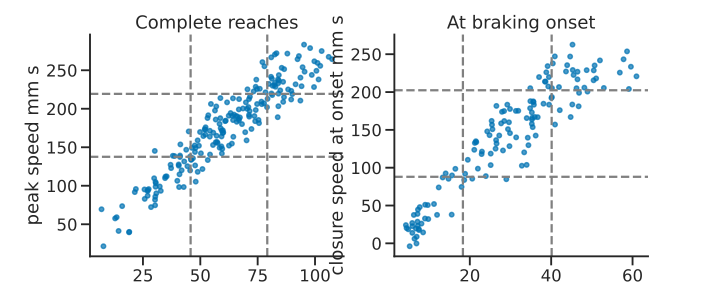

In [104]:
support_plots = [
    (straight_reach_support, 'total_distance_mm', 'peak_speed_mm_s', 'Complete reaches'),
    (onset_support, 'remaining_gap_at_onset_mm', 'closure_speed_at_onset_mm_s', 'At braking onset'),
]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (data, x, y, title) in zip(axes, support_plots):
    ax.scatter(data[x], data[y], s=20, alpha=0.7)
    for value in data[x].quantile([0.25, 0.75]):
        ax.axvline(value, color='grey', linestyle='--')
    for value in data[y].quantile([0.25, 0.75]):
        ax.axhline(value, color='grey', linestyle='--')
    ax.set(xlabel=x.replace('_', ' '), ylabel=y.replace('_', ' '), title=title)
plt.show()


In [105]:
def summarize_support(data, x, y, comparison):
    x25, x75 = data[x].quantile([0.25, 0.75])
    y25, y75 = data[y].quantile([0.25, 0.75])
    return {
        'comparison': comparison,
        'n': len(data),
        'pearson_r': data[[x, y]].corr().iloc[0, 1],
        'spearman_rho': data[[x, y]].corr(method='spearman').iloc[0, 1],
        'low_distance_low_speed_n': ((data[x] <= x25) & (data[y] <= y25)).sum(),
        'low_distance_high_speed_n': ((data[x] <= x25) & (data[y] >= y75)).sum(),
        'high_distance_low_speed_n': ((data[x] >= x75) & (data[y] <= y25)).sum(),
        'high_distance_high_speed_n': ((data[x] >= x75) & (data[y] >= y75)).sum(),
    }

behavioral_support_report = pd.DataFrame([
    summarize_support(
        straight_reach_support, 'total_distance_mm', 'peak_speed_mm_s',
        'Total distance vs peak speed',
    ),
    summarize_support(
        onset_support, 'remaining_gap_at_onset_mm', 'closure_speed_at_onset_mm_s',
        'Onset gap vs closure speed',
    ),
])
print('Low/high groups are the bottom/top quartiles; the middle 50% is not counted.')
behavioral_support_report


Low/high groups are the bottom/top quartiles; the middle 50% is not counted.


,comparison,n,pearson_r,spearman_rho,low_distance_low_speed_n,low_distance_high_speed_n,high_distance_low_speed_n,high_distance_high_speed_n
0,Total distance vs peak speed,203,0.939354,0.937669,43,0,0,42
1,Onset gap vs closure speed,139,0.930097,0.928433,32,0,0,27


In [106]:
distance_bin_labels = ['Q1 shortest', 'Q2', 'Q3', 'Q4', 'Q5 longest']

straight_reach_support_binned = straight_reach_support.copy()
straight_reach_support_binned['distance_bin'] = pd.qcut(
    straight_reach_support_binned['total_distance_mm'], 5, labels=distance_bin_labels,
)

onset_support_binned = onset_support.copy()
onset_support_binned['distance_bin'] = pd.qcut(
    onset_support_binned['remaining_gap_at_onset_mm'], 5, labels=distance_bin_labels,
)


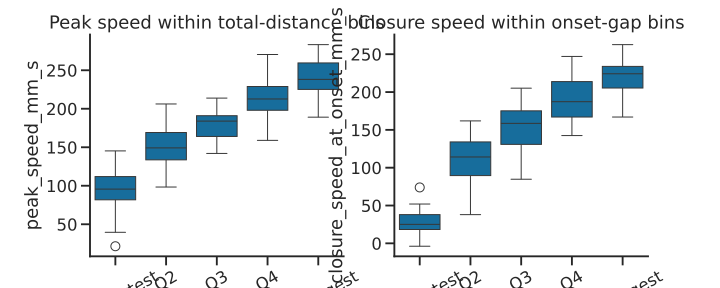

In [107]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(
    data=straight_reach_support_binned, x='distance_bin', y='peak_speed_mm_s',
    ax=axes[0], color=PALETTE[0],
)
sns.boxplot(
    data=onset_support_binned, x='distance_bin', y='closure_speed_at_onset_mm_s',
    ax=axes[1], color=PALETTE[0],
)
axes[0].set(title='Peak speed within total-distance bins', xlabel='Total-distance quintile')
axes[1].set(title='Closure speed within onset-gap bins', xlabel='Onset-gap quintile')
for ax in axes:
    ax.tick_params(axis='x', rotation=30)
plt.show()


In [108]:
def summarize_conditional_support(data, distance, speed, comparison):
    grouped = data.groupby('distance_bin', observed=True)
    bin_report = grouped.agg(
        n=(speed, 'size'),
        distance_min=(distance, 'min'),
        distance_max=(distance, 'max'),
        speed_q25=(speed, lambda values: values.quantile(0.25)),
        speed_median=(speed, 'median'),
        speed_q75=(speed, lambda values: values.quantile(0.75)),
    )
    bin_report['speed_iqr'] = bin_report['speed_q75'] - bin_report['speed_q25']
    bin_report['normalized_speed_iqr'] = bin_report['speed_iqr'] / bin_report['speed_median']
    residual_speed = data[speed] - grouped[speed].transform('mean')
    within_distance = data[distance] - grouped[distance].transform('mean')
    return bin_report, {
        'comparison': comparison,
        'remaining_speed_variance_fraction': residual_speed.var() / data[speed].var(),
        'pooled_within_bin_r': within_distance.corr(residual_speed),
    }

full_bin_report, full_summary = summarize_conditional_support(
    straight_reach_support_binned, 'total_distance_mm', 'peak_speed_mm_s',
    'Total distance vs peak speed',
)
onset_bin_report, onset_summary = summarize_conditional_support(
    onset_support_binned, 'remaining_gap_at_onset_mm', 'closure_speed_at_onset_mm_s',
    'Onset gap vs closure speed',
)
conditional_support_summary = pd.DataFrame([full_summary, onset_summary])
display(conditional_support_summary)
display(full_bin_report)
display(onset_bin_report)


,comparison,remaining_speed_variance_fraction,pooled_within_bin_r
0,Total distance vs peak speed,0.182349,0.622933
1,Onset gap vs closure speed,0.122369,0.382388


,n,distance_min,distance_max,speed_q25,speed_median,speed_q75,speed_iqr,normalized_speed_iqr
distance_bin,,,,,,,,
Q1 shortest,41,6.948243,41.138244,81.759956,95.692056,111.920732,30.160776,0.315186
Q2,40,41.154350,56.390871,133.654215,149.137618,169.149247,35.495032,0.238002
Q3,41,56.701488,68.596039,164.029139,183.931971,190.971249,26.942110,0.146479
Q4,40,69.569972,82.502130,198.053148,212.746537,228.892125,30.838977,0.144956
Q5 longest,41,82.531291,107.446690,225.137825,238.155189,259.507673,34.369848,0.144317


,n,distance_min,distance_max,speed_q25,speed_median,speed_q75,speed_iqr,normalized_speed_iqr
distance_bin,,,,,,,,
Q1 shortest,28,4.288646,12.359568,18.332816,25.123464,37.969139,19.636323,0.781593
Q2,28,13.324463,26.459569,89.573790,114.210697,134.070367,44.496576,0.389601
Q3,27,26.535313,34.883877,130.837198,158.572933,175.154773,44.317575,0.279478
Q4,28,35.242672,42.114409,166.971149,187.254325,213.806085,46.834936,0.250114
Q5 longest,28,43.640731,60.964026,205.312623,224.137344,233.902018,28.589395,0.127553


In [109]:
MATCH_DISTANCE_TOLERANCE_MM = 3.0
MIN_MATCH_SPEED_RATIO = 1.5

full_match_candidates = find_distance_matched_pairs(
    straight_reach_support['reach'], straight_reach_support['total_distance_mm'],
    straight_reach_support['peak_speed_mm_s'],
    max_distance_difference=MATCH_DISTANCE_TOLERANCE_MM,
    min_speed_ratio=MIN_MATCH_SPEED_RATIO,
)
onset_match_candidates = find_distance_matched_pairs(
    onset_support['reach'], onset_support['remaining_gap_at_onset_mm'],
    onset_support['closure_speed_at_onset_mm_s'],
    max_distance_difference=MATCH_DISTANCE_TOLERANCE_MM,
    min_speed_ratio=MIN_MATCH_SPEED_RATIO,
)
full_matched_pairs = full_match_candidates[full_match_candidates['selected']]
onset_matched_pairs = onset_match_candidates[onset_match_candidates['selected']]


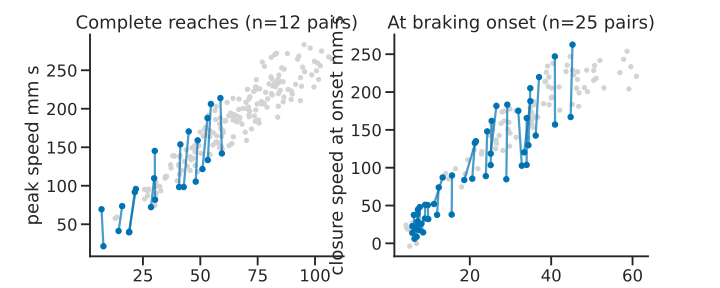

In [110]:
matched_pair_plots = [
    (straight_reach_support, full_matched_pairs, 'total_distance_mm', 'peak_speed_mm_s', 'Complete reaches'),
    (onset_support, onset_matched_pairs, 'remaining_gap_at_onset_mm', 'closure_speed_at_onset_mm_s', 'At braking onset'),
]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (data, pairs, distance, speed, title) in zip(axes, matched_pair_plots):
    ax.scatter(data[distance], data[speed], s=15, color='lightgrey')
    for pair in pairs.itertuples(index=False):
        matched = data[data['reach'].isin([pair.first_id, pair.second_id])]
        ax.plot(matched[distance], matched[speed], color=PALETTE[0], alpha=0.7)
        ax.scatter(matched[distance], matched[speed], s=25, color=PALETTE[0])
    ax.set(xlabel=distance.replace('_', ' '), ylabel=speed.replace('_', ' '))
    ax.set_title(f'{title} (n={len(pairs)} pairs)')
plt.show()


In [111]:
def matched_pair_summary(candidates, comparison, total_reaches, tolerance, speed_ratio):
    eligible_reaches = set(candidates['first_id']) | set(candidates['second_id'])
    return {
        'comparison': comparison,
        'distance_tolerance_mm': tolerance,
        'minimum_speed_ratio': speed_ratio,
        'total_reaches': total_reaches,
        'candidate_pair_n': len(candidates),
        'eligible_reach_n': len(eligible_reaches),
        'non_reused_pair_n': int(candidates['selected'].sum()),
    }

primary_match_report = pd.DataFrame([
    matched_pair_summary(
        full_match_candidates, 'Total distance vs peak speed', len(straight_reach_support),
        MATCH_DISTANCE_TOLERANCE_MM, MIN_MATCH_SPEED_RATIO,
    ),
    matched_pair_summary(
        onset_match_candidates, 'Onset gap vs closure speed', len(onset_support),
        MATCH_DISTANCE_TOLERANCE_MM, MIN_MATCH_SPEED_RATIO,
    ),
])

sensitivity_rows = []
for comparison, data, distance, speed in [
    ('Total distance vs peak speed', straight_reach_support, 'total_distance_mm', 'peak_speed_mm_s'),
    ('Onset gap vs closure speed', onset_support, 'remaining_gap_at_onset_mm', 'closure_speed_at_onset_mm_s'),
]:
    for tolerance in [1.0, 2.0, 3.0, 5.0]:
        for speed_ratio in [1.25, 1.5, 2.0]:
            candidates = find_distance_matched_pairs(
                data['reach'], data[distance], data[speed],
                max_distance_difference=tolerance, min_speed_ratio=speed_ratio,
            )
            sensitivity_rows.append(matched_pair_summary(
                candidates, comparison, len(data), tolerance, speed_ratio,
            ))
distance_match_sensitivity = pd.DataFrame(sensitivity_rows)
display(primary_match_report)
distance_match_sensitivity


,comparison,distance_tolerance_mm,minimum_speed_ratio,total_reaches,candidate_pair_n,eligible_reach_n,non_reused_pair_n
0,Total distance vs peak speed,3.0,1.5,203,23,31,12
1,Onset gap vs closure speed,3.0,1.5,139,223,93,25


,comparison,distance_tolerance_mm,minimum_speed_ratio,total_reaches,candidate_pair_n,eligible_reach_n,non_reused_pair_n
0,Total distance vs peak speed,1.0,1.25,203,81,86,29
1,Total distance vs peak speed,1.0,1.50,203,8,13,5
2,Total distance vs peak speed,1.0,2.00,203,1,2,1
3,Total distance vs peak speed,2.0,1.25,203,156,128,36
4,Total distance vs peak speed,2.0,1.50,203,14,21,8
5,Total distance vs peak speed,2.0,2.00,203,2,4,2
6,Total distance vs peak speed,3.0,1.25,203,230,149,41
7,Total distance vs peak speed,3.0,1.50,203,23,31,12
8,Total distance vs peak speed,3.0,2.00,203,6,8,4
9,Total distance vs peak speed,5.0,1.25,203,399,164,47
